This notebook is used to create the ICD Genetic Network

In [1]:
import numpy as np
import networkx as nx
import itertools as it
import random as rd
import pickle as pk
import pandas as pd
from collections import (defaultdict,Counter)
import matplotlib.pyplot as plt
import scipy  
from scipy import stats


In [53]:
def overlap_jaccard(list1,list2):
    intersction_term= len(set(list1) & set(list2))
    denominator = len(set(list1).union(set(list2)))
    overlap_jaccard_coeff = intersction_term/denominator
    return overlap_jaccard_coeff

def overlap_genelists(lstA, lstB, background):
    import scipy.stats as stats
    """
    Accepts to lists
    M is the population size (previously N)
    n is the number of successes in the population
    N is the sample size (previously n)
    x is still the number of drawn “successes”
    """
    setA= set(lstA)
    setB= set(lstB)
    M= background #total number of genes
    n= len(setA)
    N= len(setB)
    x= len(setA.intersection(setB))

    return str(stats.hypergeom.sf(x-1, M, n, N))



#Here we define the adjustment
from statsmodels.sandbox.stats.multicomp import multipletests
def fdr_adjustment(list_of_pvals,alpha):    
    return multipletests(list_of_pvals,alpha=alpha,method='fdr_bh')[1] #the benjamin hochberg method is used

In [3]:
#Here, we define the PPI
ppi = pd.read_csv("input/autocore_ppi_symbol_lcc.csv",delimiter= ',',
           skipinitialspace=True)
G_ppi = nx.from_pandas_edgelist(ppi, 'symbol1', 'symbol2')

In [7]:
#Let's import the ICD-gene associations
with open('output/allsources_icd_gene_dict_unified_v2026_official.pickle', 'rb') as handle:
    allsources_icd_gene_dict_unified = pk.load(handle)

In [5]:
icd_cat = set([i[0] for i in allsources_icd_gene_dict_unified.keys()])

In [61]:
#Let's import the unified gene annotations lcc z-score
with open('output/allsources_icd_gene_dict_unified_lcczscore_v2026_official.pickle', 'rb') as handle:
    allsources_icd_gene_dict_unified_lcczscore = pk.load(handle)


In [8]:
#Let's create a network that takes into account the shared genetic component of these diseases

from itertools import combinations

dis_gene_overlap_pval_dict = {}

for (dis1, genelist1), (dis2, genelist2) in combinations(
    allsources_icd_gene_dict_unified.items(), 2
):
    pval_ov = float(overlap_genelists(genelist1, genelist2, 11378))
    dis_gene_overlap_pval_dict[(dis1, dis2)] = pval_ov
    

In [9]:
len(dis_gene_overlap_pval_dict)

292995

In [10]:

dis_gene_overlap_fdr_dict={}
dis_gene_overlap_sigfdr_dict={}

adj_pval=fdr_adjustment(list(dis_gene_overlap_pval_dict.values()),0.05)
pair_list=list(dis_gene_overlap_pval_dict.keys())
for i in range(len(adj_pval)):
    dis_gene_overlap_fdr_dict[pair_list[i]]=adj_pval[i]
        
for dispair,fdr in dis_gene_overlap_fdr_dict.items():
    if fdr<0.05:
        dis_gene_overlap_sigfdr_dict[dispair]=fdr
    
print(len(dis_gene_overlap_sigfdr_dict))

7477


In [31]:
#Let's define the odds ratio between two genesets
def oddsratio(set1,set2,background):
    from scipy.stats import fisher_exact
    
    intersect = len(set1 & set2)
    set1_diff = len(set1) - intersect
    set2_diff = len(set2) - intersect
    background_diff = background - len(set1) - len(set2) + intersect
    
    # Create contingency table
    contingency_table = [[intersect, set1_diff], [set2_diff, background_diff]]
    
    # Perform Fisher's exact test
    oddsratio = fisher_exact(contingency_table)[0]
    
    return oddsratio

In [11]:
#Let's do it with the Jaccard Index

def jaccard_index(set1,set2):
    intersect = len(set1 & set2)
    union = len(set1.union(set2))
    ratio = intersect/union
    return ratio

G_gene_icd = nx.Graph()  # or DiGraph, MultiGraph, MultiDiGraph, etc
#for dis_pair,fdr in dis_gene_overlap_sigfdr_dict.items():
    #ji_weight= jaccard_index(allsources_icd_gene_dict_unified[dis_pair[0]],allsources_icd_gene_dict_unified[dis_pair[1]])
    #G_gene_icd.add_edge(dis_pair[0], dis_pair[1], weight=ji_weight)

eps = 1e-300
max_weight = 50

for dis_pair, fdr in dis_gene_overlap_sigfdr_dict.items():
    fdr_safe = max(fdr, eps)
    weight_colog = min(-np.log(fdr_safe), max_weight)
    G_gene_icd.add_edge(dis_pair[0], dis_pair[1], weight=weight_colog)
    

print(G_gene_icd.number_of_nodes())
print(G_gene_icd.number_of_edges())

660
7477


In [12]:
G_gene_icd_degree=dict(nx.degree(G_gene_icd))
dict(sorted(G_gene_icd_degree.items(), key=lambda item: item[1],reverse=True))

{'E10': 147,
 'H20': 134,
 'J18': 132,
 'M35': 131,
 'I22': 128,
 'N17': 127,
 'H36': 124,
 'N08': 124,
 'C22': 117,
 'J45': 115,
 'J44': 114,
 'F48': 114,
 'M06': 111,
 'A15': 106,
 'I10': 102,
 'I51': 99,
 'N18': 99,
 'M08': 98,
 'M33': 97,
 'I64': 97,
 'I70': 94,
 'L63': 93,
 'I20': 92,
 'K50': 91,
 'K51': 89,
 'M31': 89,
 'K52': 88,
 'L80': 87,
 'C50': 86,
 'E11': 86,
 'K70': 85,
 'L40': 84,
 'D64': 83,
 'K13': 83,
 'F31': 83,
 'L10': 82,
 'B55': 81,
 'F10': 80,
 'C16': 80,
 'I25': 79,
 'I50': 79,
 'A48': 77,
 'C53': 76,
 'L71': 75,
 'G35': 75,
 'M32': 75,
 'M81': 75,
 'K90': 74,
 'K76': 74,
 'F39': 72,
 'E84': 71,
 'I00': 69,
 'I63': 69,
 'J62': 69,
 'F30': 69,
 'E31': 68,
 'D70': 67,
 'D86': 67,
 'C90': 67,
 'I60': 65,
 'J30': 65,
 'E66': 63,
 'B22': 62,
 'L12': 61,
 'L57': 61,
 'L51': 59,
 'K25': 59,
 'L23': 59,
 'A49': 58,
 'K75': 58,
 'E16': 57,
 'G36': 57,
 'J63': 57,
 'L20': 57,
 'C80': 57,
 'A01': 55,
 'A16': 55,
 'J80': 55,
 'K82': 55,
 'E06': 54,
 'F12': 54,
 'M05': 54,
 

In [13]:
#The resulted network is a little bit too dense, so I will use a disparity filter for reducing the number of edges
from scipy import integrate
#Here we define the disparity filter for backboning our future networks.
def disparity_filter(G, weight='weight'):
    ''' Compute significance scores (alpha) for weighted edges in G as defined in Serrano et al. 2009
        Args
            G: Weighted NetworkX graph
        Returns
            Weighted graph with a significance score (alpha) assigned to each edge
        References
            M. A. Serrano et al. (2009) Extracting the Multiscale backbone of complex weighted networks. PNAS, 106:16, pp. 6483-6488.
    '''
    if nx.is_directed(G): #directed case
        N = nx.DiGraph()
        for u in G:
            k_out = G.out_degree(u)
            k_in = G.in_degree(u)
            if k_out > 1:
                sum_w_out = sum(np.absolute(G[u][v][weight]) for v in G.successors(u))
                for v in G.successors(u):
                    w = G[u][v][weight]
                    p_ij_out = float(np.absolute(w))/sum_w_out
                    alpha_ij_out = 1 - (k_out-1) * integrate.quad(lambda x: (1-x)**(k_out-2), 0, p_ij_out)[0]
                    N.add_edge(u, v, weight = w, alpha_out=float('%.4f' % alpha_ij_out))
            elif k_out == 1 and G.in_degree(G.successors(u)[0]) == 1:
                #we need to keep the connection as it is the only way to maintain the connectivity of the network
                v = G.successors(u)[0]
                w = G[u][v][weight]
                N.add_edge(u, v, weight = w, alpha_out=0., alpha_in=0.)
                #there is no need to do the same for the k_in, since the link is built already from the tail
            if k_in > 1:
                sum_w_in = sum(np.absolute(G[v][u][weight]) for v in G.predecessors(u))
                for v in G.predecessors(u):
                    w = G[v][u][weight]
                    p_ij_in = float(np.absolute(w))/sum_w_in
                    alpha_ij_in = 1 - (k_in-1) * integrate.quad(lambda x: (1-x)**(k_in-2), 0, p_ij_in)[0]
                    N.add_edge(v, u, weight = w, alpha_in=float('%.4f' % alpha_ij_in))
        return N
    else: #undirected case
        B = nx.Graph()
        for u in G:
            k = len(G[u])
            if k > 1:
                sum_w = sum(np.absolute(G[u][v][weight]) for v in G[u])
                for v in G[u]:
                    w = G[u][v][weight]
                    p_ij = float(np.absolute(w))/sum_w
                    alpha_ij = 1 - (k-1) * integrate.quad(lambda x: (1-x)**(k-2), 0, p_ij)[0]
                    B.add_edge(u, v, weight = w, alpha=float('%.4f' % alpha_ij))
        return B



In [14]:
#sparsifying the network by applying disparity filter
G_gene_icd_disp = disparity_filter(G_gene_icd)
#Let's filter until we keep all nodes (atoms) in our network
alpha_cutoff_list=[0.95,0.9,0.8,0.7,0.6,0.5,0.4,0.3,0.2,0.1,0.05,0.03,0.01]
alpha_nodes_dict={}
for alpha in alpha_cutoff_list:
    G_gene_icd_disp_significant = nx.Graph([(u, v, d) for u, v, d in G_gene_icd_disp.edges(data=True) if d['alpha'] < alpha])
    filtered_G_nodes=G_gene_icd_disp_significant.number_of_nodes()
    filtered_G_edges=G_gene_icd_disp_significant.number_of_edges()
    alpha_nodes_dict[str(alpha)]=[filtered_G_nodes,filtered_G_edges]
    


In [15]:
alpha_nodes_dict

{'0.95': [648, 7471],
 '0.9': [648, 7467],
 '0.8': [642, 7317],
 '0.7': [634, 6625],
 '0.6': [628, 5528],
 '0.5': [607, 4228],
 '0.4': [562, 2859],
 '0.3': [508, 1830],
 '0.2': [399, 1067],
 '0.1': [275, 508],
 '0.05': [186, 263],
 '0.03': [148, 156],
 '0.01': [63, 35]}

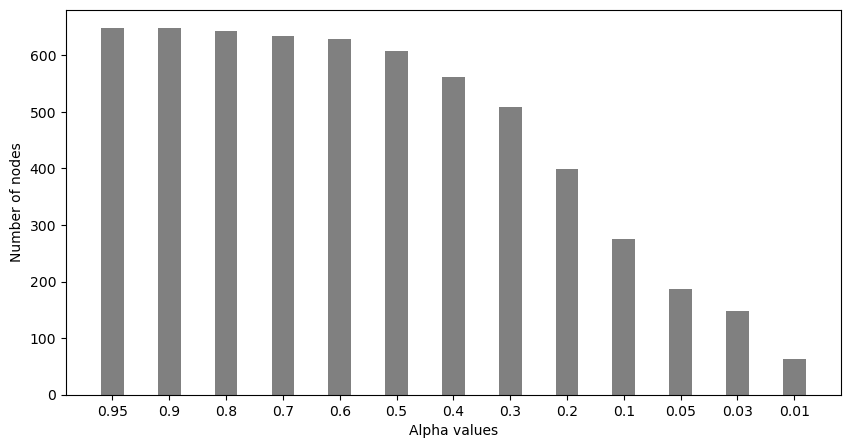

In [16]:

alpha_values = list(alpha_nodes_dict.keys())
nodes = list(i[0] for i in alpha_nodes_dict.values())
 
fig = plt.figure(figsize = (10, 5))

# creating the bar plot
plt.bar(alpha_values, nodes, color ='grey', 
        width = 0.4)

plt.xlabel("Alpha values")
plt.ylabel("Number of nodes")
plt.savefig('Figures/Supplementary_Genetic_Network_aplha_thresholds_nodes_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")

plt.show()

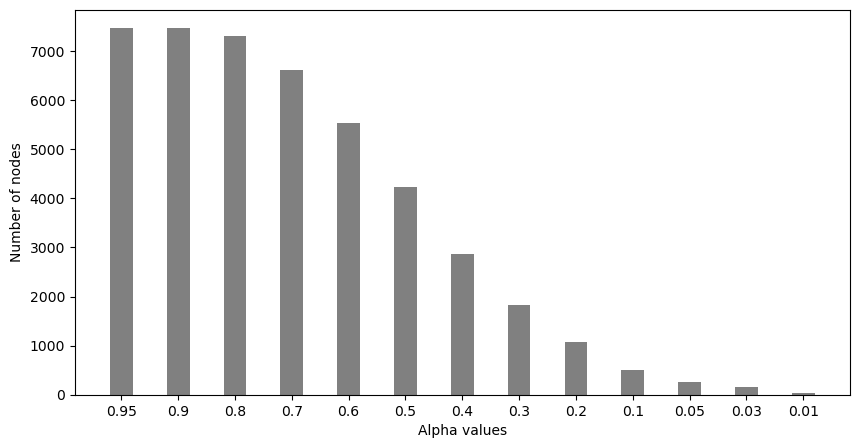

In [17]:
alpha_values = list(alpha_nodes_dict.keys())
edges = list(i[1] for i in alpha_nodes_dict.values())
 
fig = plt.figure(figsize = (10, 5))

# creating the bar plot
plt.bar(alpha_values, edges, color ='grey', 
        width = 0.4)

plt.xlabel("Alpha values")
plt.ylabel("Number of nodes")
plt.savefig('Figures/Supplementary_Genetic_Network_aplha_thresholds_edges_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")

plt.show()

In [19]:
#Let's use 0.5 as a threshold
G_gene_icd_disp = disparity_filter(G_gene_icd)
G_gene_icd_disp_significant_post = nx.Graph([(u, v, d) for u, v, d in G_gene_icd_disp.edges(data=True) if d['alpha'] < 0.5])
print(G_gene_icd_disp_significant_post.number_of_nodes(), G_gene_icd_disp_significant_post.number_of_edges())


607 4228


In [20]:
G_gene_icd_disp_significant_post_df = nx.to_pandas_edgelist(G_gene_icd_disp_significant_post,'Dis A', 'Dis B')
G_gene_icd_disp_significant_post_df.to_csv('output/G_gene_icd_disp_significant_post_df_v2026_official.tsv', sep = '\t')


In [2]:
#Let's import the ICD Genetic network
G_gene_icd_disp_significant_post_df = pd.read_csv("output/G_gene_icd_disp_significant_post_df_v2026_official.tsv", sep="\t",index_col=0)
G_gene_icd_disp_significant_post = nx.from_pandas_edgelist(
    G_gene_icd_disp_significant_post_df,
    source='Dis A',
    target='Dis B',
    edge_attr='weight',     # or a list of columns
    create_using=nx.Graph()
)

In [3]:
#Let's extract the ICD categories
icd_cat = set([str(n[0]) for n in G_gene_icd_disp_significant_post.nodes()])

# Generate a color map with `len(elements)` unique colors
cmap = plt.get_cmap('tab20')  

# Function to convert RGBA to HEX
def rgba_to_hex(rgba):
    return '#{:02x}{:02x}{:02x}'.format(int(rgba[0] * 255), int(rgba[1] * 255), int(rgba[2] * 255))


# Ensure you have enough unique colors in the chosen colormap
num_colors = len(icd_cat)
colors = [cmap(i) for i in range(num_colors)]
# Convert colors to hex
hex_colors = [rgba_to_hex(color) for color in colors]

# Create a dictionary to map each element to a unique color
icd_cat_color_mapping = {elem: color for elem, color in zip(icd_cat, hex_colors)}



In [4]:
import re

def icd_chapter(code):
    if not isinstance(code, str):
        return None

    code = code.upper()

    L = code[0]

    m = re.search(r'^[A-Z](\d{2})', code)
    if m is None:
        return None

    N = int(m.group(1))

    if L in ("A", "B"):
        return "I"
    if L == "C" or (L == "D" and N <= 48):
        return "II"
    if L == "D" and N >= 50:
        return "III"
    if L == "E":
        return "IV"
    if L == "F":
        return "V"
    if L == "G":
        return "VI"
    if L == "H" and N <= 59:
        return "VII"
    if L == "H" and N >= 60:
        return "VIII"
    if L == "I":
        return "IX"
    if L == "J":
        return "X"
    if L == "K":
        return "XI"
    if L == "L":
        return "XII"
    if L == "M":
        return "XIII"
    if L == "N":
        return "XIV"
    if L == "O":
        return "XV"
    if L == "P":
        return "XVI"
    if L == "Q":
        return "XVII"
    if L == "R":
        return "XVIII"
    if L in ("S", "T"):
        return "XIX"
    if L in ("V", "W", "X", "Y"):
        return "XX"
    if L == "Z":
        return "XXI"
    if L == "U":
        return "XXII"

    return None

chapter_colors = {
    "I":    "#4589FF",
    "II":   "#00A3FF",
    "III":  "#00B5F1",
    "IV":   "#00C2CD",
    "V":    "#00CAA5",
    "VI":   "#53CD85",
    "VII":  "#7CCD66",
    "VIII": "#A3CA47",
    "IX":   "#CAC42A",
    "X":    "#EBB71E",
    "XI":   "#F9A22C",
    "XII":  "#FF8C3F",
    "XIII": "#FF7852",
    "XIV":  "#FF6666",
    "XV":   "#D65DB1",
    "XVI":  "#845EC2",
    "XVII": "#0081CF",
    "XVIII":"#2C73D2",
    "XIX":  "#008E9B",
    "XX":   "#008F7A",
    "XXI":  "#FFC75F",
    "XXII": "#F9F871"
}

icd_letter_to_color = {}

for letter in list("ABCDEFGHIJKLMNOPQRSTUVWXYZ"):
    # fake code to trigger chapter logic
    fake_code = f"{letter}00"
    chapter = icd_chapter(fake_code)

    if chapter is not None:
        icd_letter_to_color[letter] = chapter_colors[chapter]

In [44]:
with open('output/icd_cat_color_mapping.pickle', 'wb') as handle:
    pk.dump(icd_cat_color_mapping, handle, protocol=pk.HIGHEST_PROTOCOL)

In [5]:
with open('output/icd_cat_color_mapping.pickle', 'rb') as handle:
    icd_cat_color_mapping = pk.load(handle)

In [8]:
icd_cat_genedict = {}
for icd in icd_cat:
    genelist = []
    for icd_code,geneset in allsources_icd_gene_dict_unified.items():
        if icd in icd_code:
            genelist.extend(list(geneset))
    icd_cat_genedict[icd] = set(genelist)

for cat,geneset in icd_cat_genedict.items():
    print(cat,len(geneset))

C 1213
E 1816
G 2537
I 2052
J 1266
N 832
F 2050
M 1998
D 889
L 1777
H 2230
K 2124
B 500
A 254


In [9]:
from cartoGRAPHs import *
import random 
from sklearn.decomposition import PCA
from sklearn import preprocessing
import json
import matplotlib.colors as mcolors
import colorsys
import pickle as pk

In [10]:
icd_code_comm = {}
for icd in icd_cat:
    nodelist = []
    for node in G_gene_icd_disp_significant_post.nodes():
        if icd in node:
            nodelist.append(node)
    icd_code_comm[icd] = nodelist

In [11]:
# creating a feature dataframe based on community
feature_df = pd.DataFrame()
    
for g in G_gene_icd_disp_significant_post.nodes():
    feature_list=[]
    for icd, nodelist in icd_code_comm.items():
        if g in nodelist:
            feature_list.append(1)
        else:
            feature_list.append(0)
    feature_df[g]=feature_list


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_19660/3196354452.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_df[g]=feature_list
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_19660/3196354452.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_df[g]=feature_list
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_19660/3196354452.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfor

In [12]:
feature_df_T=feature_df.T

In [13]:
r = 0.9
alpha = 1.0

A = nx.adjacency_matrix(G_gene_icd_disp_significant_post, nodelist=list(G_gene_icd_disp_significant_post.nodes()))
DM_m = rnd_walk_matrix2(A, r, alpha, len(G_gene_icd_disp_significant_post.nodes()))
FM_structural = pd.DataFrame(DM_m)
FM_structural.sum(axis=1) # axis=1 for columns i.e. features = sum 1
FM_structural.index=list(G_gene_icd_disp_significant_post.nodes())
FM_structural.columns=list(G_gene_icd_disp_significant_post.nodes())
FM_structural

,A01,A15,A30,A49,B07,B41,B55,B67,C51,C53,...,B47,K07,D29,D40,D51,D53,F63,F95,J04,J02
A01,9.003588e-01,1.515924e-03,3.528527e-03,2.652726e-03,1.313183e-02,6.224496e-03,1.533697e-03,4.093259e-03,4.216096e-03,1.511526e-03,...,0.0,0.0,0.0,0.0,2.043268e-12,2.043268e-12,0.000000,0.000000,0.000000,0.000000
A15,5.012804e-03,9.003785e-01,5.269843e-03,8.400614e-03,7.891324e-05,1.144779e-04,1.838154e-03,4.680294e-03,2.657992e-03,7.523342e-03,...,0.0,0.0,0.0,0.0,1.861431e-11,1.861431e-11,0.000000,0.000000,0.000000,0.000000
A30,2.940174e-03,1.327926e-03,9.002174e-01,3.503331e-05,4.394063e-05,7.000756e-05,2.677286e-03,2.520850e-05,3.833380e-05,3.973131e-05,...,0.0,0.0,0.0,0.0,1.378038e-12,1.378038e-12,0.000000,0.000000,0.000000,0.000000
A49,2.233154e-03,2.138622e-03,3.539386e-05,9.005648e-01,3.910624e-05,1.686976e-05,4.651838e-05,6.329555e-03,3.554231e-03,4.993007e-05,...,0.0,0.0,0.0,0.0,3.252729e-12,3.252729e-12,0.000000,0.000000,0.000000,0.000000
B07,1.283556e-03,2.332579e-06,5.154381e-06,4.540560e-06,9.006600e-01,8.876470e-06,2.564269e-06,6.197295e-06,6.516947e-06,7.754327e-06,...,0.0,0.0,0.0,0.0,2.082111e-14,2.082111e-14,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
D53,4.344731e-13,1.196964e-12,3.516571e-13,8.215976e-13,4.529516e-14,8.900999e-14,4.501191e-13,6.675317e-13,5.415737e-13,6.609809e-13,...,0.0,0.0,0.0,0.0,5.349498e-02,9.044429e-01,0.000000,0.000000,0.000000,0.000000
F63,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.909091,0.090909,0.000000,0.000000
F95,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.090909,0.909091,0.000000,0.000000
J04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000,0.000000,0.909091,0.090909


In [14]:
scalar_val = 0.95
layout_method = 'modulated-scal'+str(scalar_val)
DF_structural = FM_structural
DF_functional = feature_df
DF_merge = feature_modulation(DF_structural,DF_functional, scalar_val)

n_n = 15
spr = 2.5
md = 2.0
metr2D = 'cosine'

posG2D_modulated = layout_portrait_umap(G_gene_icd_disp_significant_post,
                                   DF_merge,
                                   2,
                                   n_neighbors=n_n, 
                                   spread=spr, 
                                   min_dist=md, 
                                   metric=metr2D
                                  )

posG2D_new = posG2D_modulated

/opt/anaconda3/envs/Epigenetics/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/Epigenetics/lib/python3.10/site-packages/umap/umap_.py:1401: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))
/opt/anaconda3/envs/Epigenetics/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [15]:
opacity_nodes = 0.9
node_edge_col = '#000000' 
node_linewidth = 0.1

#edge_opacity = 0.5
edge_width = 0.1
edge_color = '#A1A1A1' #'#6C6C6C' #'#d3d3d3'

In [16]:
def draw_node_degree(G, scalef):
    '''
    Calculate the node degree from graph positions (dict).
    Return list of radii for each node (2D). 
    '''
    
    l_size = {}
    for node in G.nodes():
        k = nx.degree(G, node)
        if k > 0:
            R = k*scalef +0.25 #math.log(k) * scalef + 0.25
        else: 
            R = 0.1
        l_size[node] = R
        
    return l_size

scale_factor = 3 #0.15
d_size = draw_node_degree(G_gene_icd_disp_significant_post, scale_factor)
l_size = [d_size[n] for n in posG2D_new.keys()]

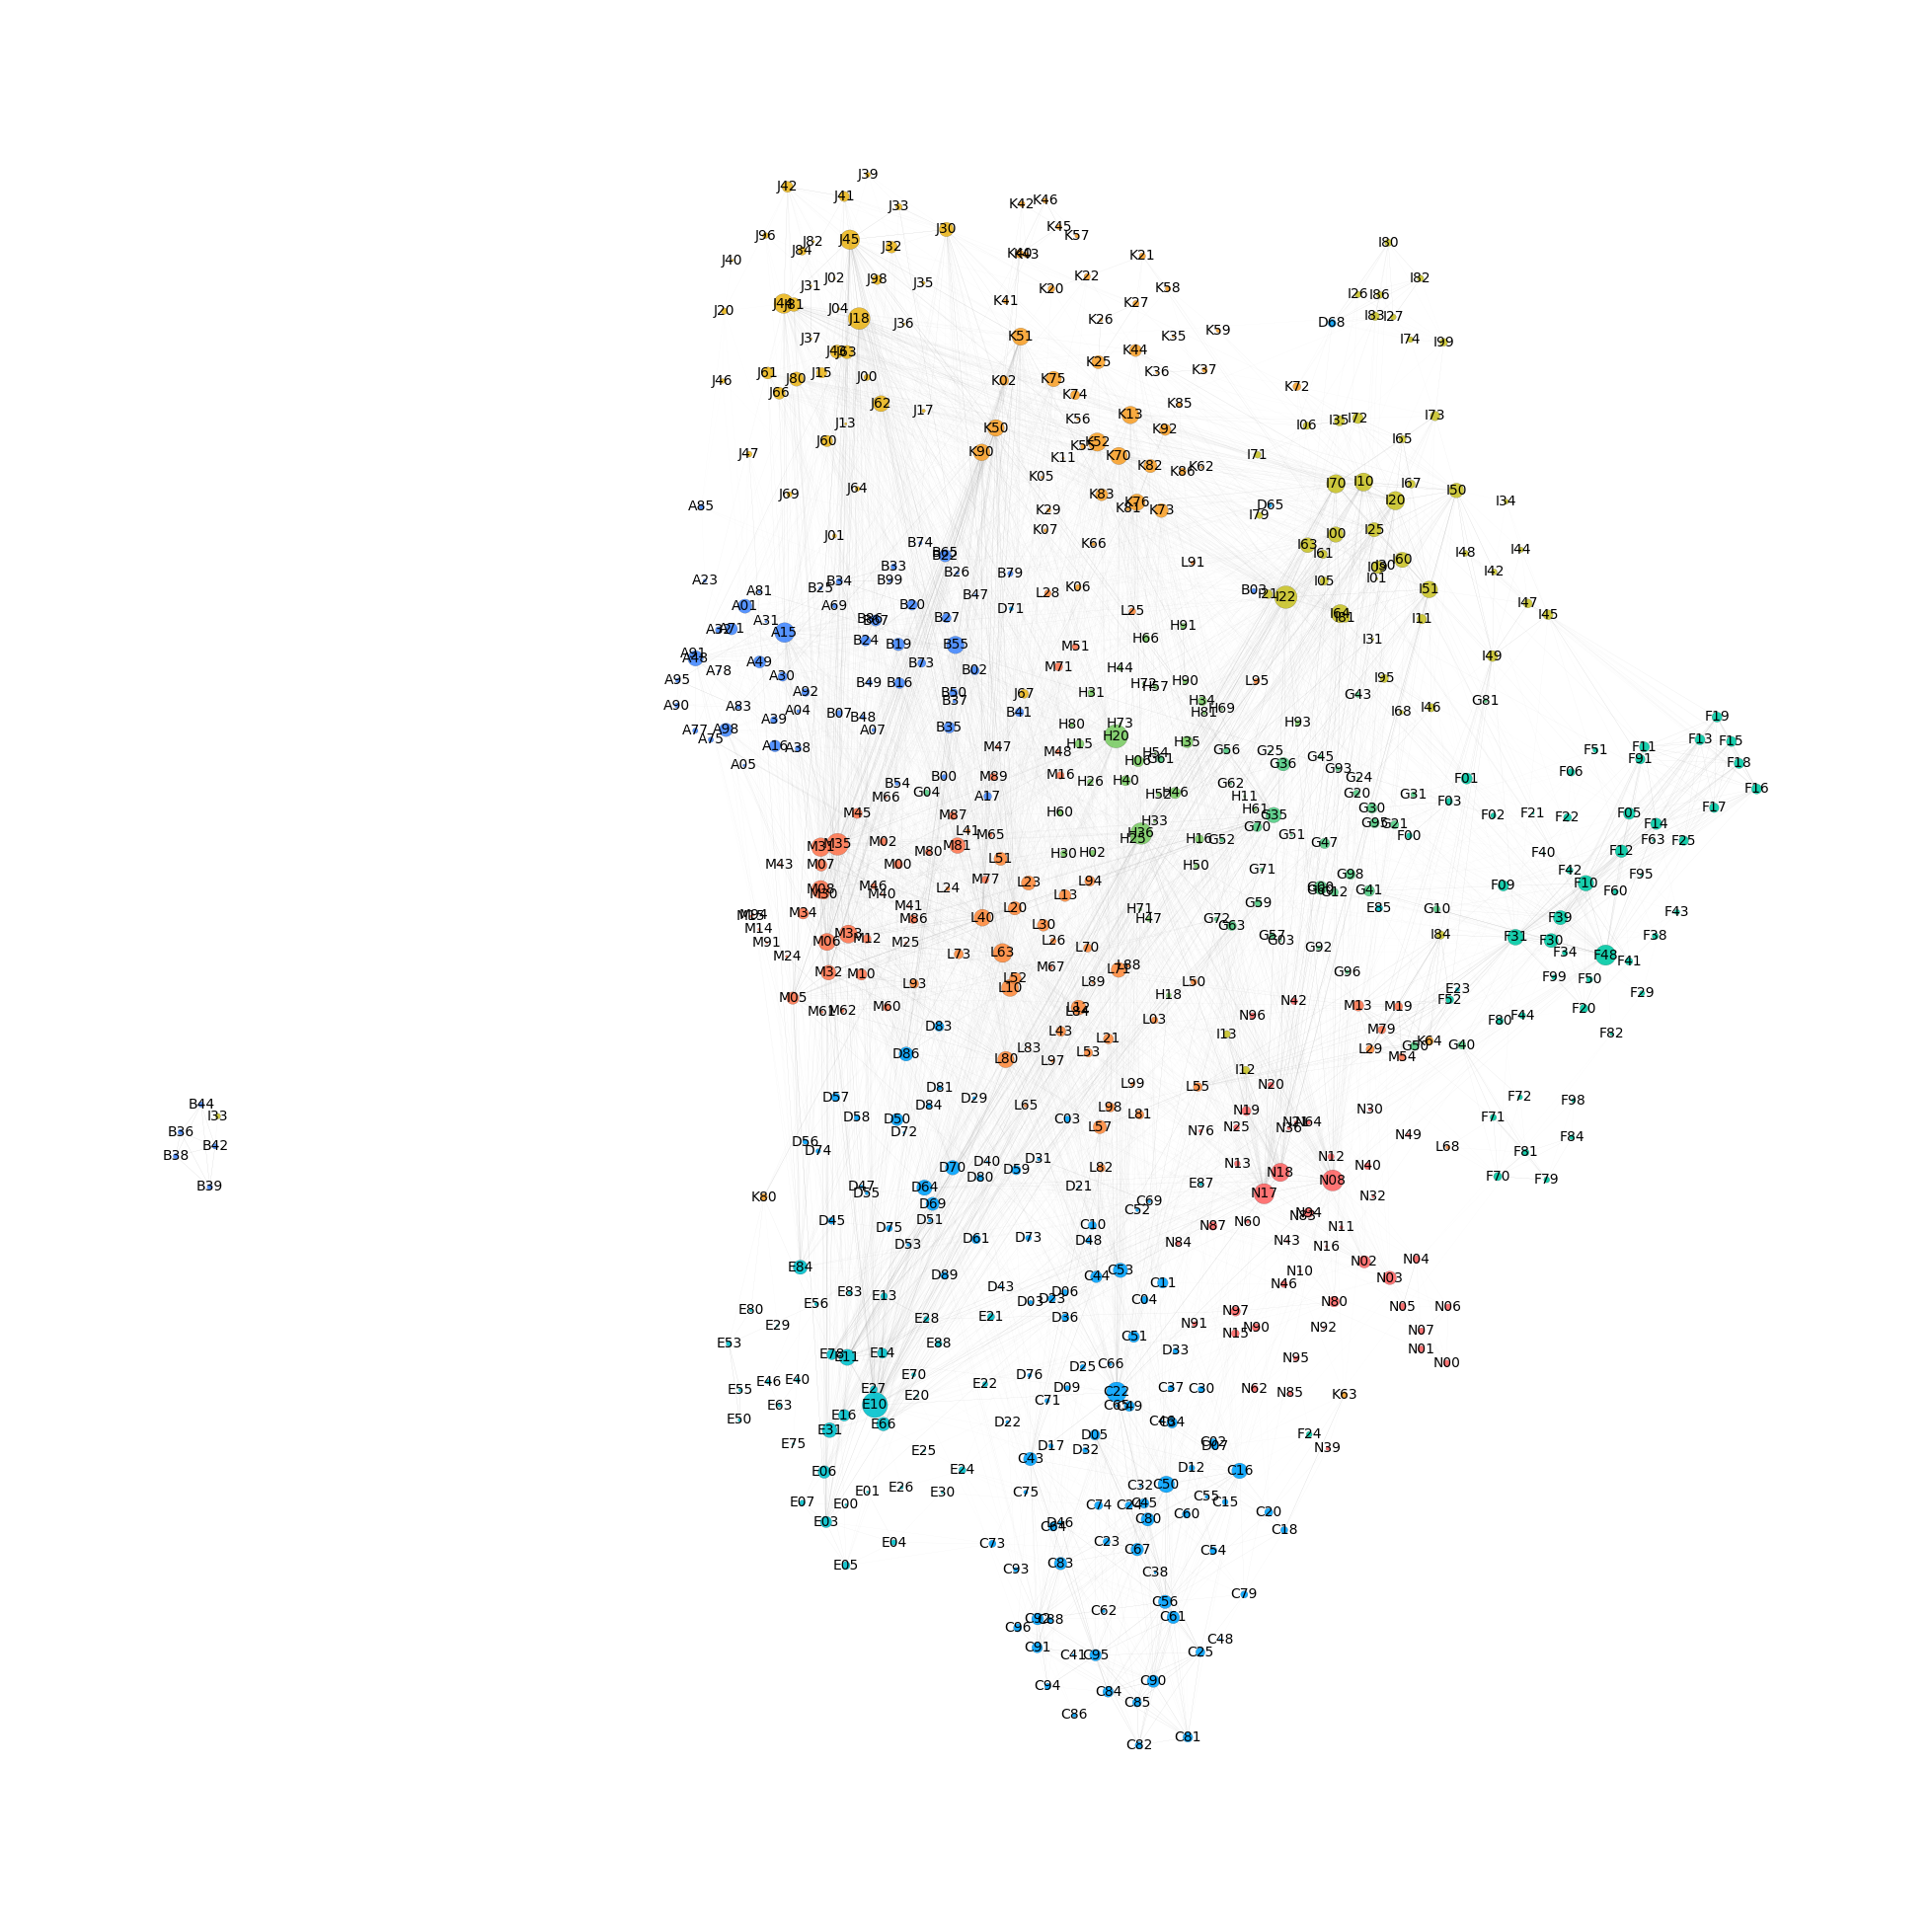

In [17]:


# Node colors
color_list = [icd_letter_to_color[node[0]] for node in G_gene_icd_disp_significant_post.nodes()]

plt.figure(figsize=(25, 25))

# Draw nodes
nx.draw_networkx_nodes(
    G_gene_icd_disp_significant_post,
    posG2D_new,
    edgecolors=node_edge_col,
    linewidths=node_linewidth,
    node_color=color_list,
    node_size=l_size,
    alpha=opacity_nodes
)

# --- Edge handling (ORDER SAFE) ---
edges = list(G_gene_icd_disp_significant_post.edges(data=True))
weights = [d["weight"] for (_, _, d) in edges]

max_width = max(weights)
min_width = min(weights)

# Normalize alpha
edge_alphas = [w / max_width for w in weights]

nx.draw_networkx_edges(
    G_gene_icd_disp_significant_post,
    posG2D_new,
    edgelist=[(u, v) for (u, v, _) in edges],
    width=edge_width,
    edge_color=edge_color,
    alpha=edge_alphas
)

plt.box(False)

nx.draw_networkx_labels(
    G_gene_icd_disp_significant_post,
    pos=posG2D_new,
    font_size=10
)

#plt.savefig(
#    "Figures/Fig1D_v2026_official.pdf",
#    format="pdf",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()



In [19]:

rows = []

for node in G_gene_icd_disp_significant_post.nodes():

    rows.append({
        "table_type": "node",
        "node": node,
        "node_color": icd_letter_to_color[node[0]],
        "node_size": l_size,
        "x_position": posG2D_new[node][0],
        "y_position": posG2D_new[node][1],
        "source_node": None,
        "target_node": None,
        "edge_weight": None,
        "edge_alpha": None
    })


edges = list(G_gene_icd_disp_significant_post.edges(data=True))
weights = [d["weight"] for (_, _, d) in edges]

max_weight = max(weights)

for (u, v, d) in edges:
    rows.append({
        "table_type": "edge",
        "node": None,
        "node_color": None,
        "node_size": None,
        "x_position": None,
        "y_position": None,
        "source_node": u,
        "target_node": v,
        "edge_weight": d["weight"],
        "edge_alpha": d["weight"] / max_weight
    })



source_df = pd.DataFrame(rows)

# Sort for deterministic ordering (important for journals)
source_df = source_df.sort_values(
    by=["table_type", "node", "source_node"],
    na_position="last"
).reset_index(drop=True)

excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl",mode="a") as writer:
    source_df.to_excel(writer, sheet_name="Fig2A", index=False)

print(f"Source data saved to {excel_path}")

Source data saved to output/SourceData.xlsx


In [28]:
G_gene_icd_disp_significant_post_degree=dict(nx.degree(G_gene_icd_disp_significant_post,weight='weight')) #Weighted degree
#G_gene_icd_disp_significant_post_degree=dict(nx.degree(G_gene_icd_disp_significant_post))
dict(sorted(G_gene_icd_disp_significant_post_degree.items(), key=lambda item: item[1],reverse=True))

{'E10': 1806.5297158768747,
 'I22': 1546.635058814949,
 'H36': 1400.8231665692892,
 'M35': 1341.42929721638,
 'M06': 1334.2113378324796,
 'J45': 1329.981309024383,
 'N17': 1235.9072050495759,
 'J18': 1220.4954018607505,
 'I10': 1216.162456069691,
 'H20': 1204.6425436240531,
 'L40': 1189.370197044188,
 'C22': 1168.5811275392205,
 'I20': 1160.280633047682,
 'N08': 1126.8534840197149,
 'F48': 1122.1521115002436,
 'K50': 1112.4540559936906,
 'N18': 1072.9656361460704,
 'I70': 1045.628611963587,
 'F31': 1020.1672354416686,
 'E11': 980.5481155238331,
 'I51': 972.936147769141,
 'J44': 958.8455087293119,
 'M32': 946.7595010167058,
 'I25': 923.2930148322397,
 'K51': 910.3716784342346,
 'G35': 884.9169440005047,
 'L63': 874.9463494716773,
 'M08': 861.2720865993049,
 'I64': 846.0323182129297,
 'I50': 834.6543227451557,
 'A15': 828.506785737749,
 'F10': 810.1481729897763,
 'K70': 807.7861121472324,
 'C56': 800.9026628676401,
 'K90': 800.7321423135267,
 'L80': 770.0730868179418,
 'M05': 744.0372054

In [21]:
node = 'E10'

sorted_neighbors = sorted(
    G_gene_icd_disp_significant_post[node].items(),
    key=lambda x: x[1].get('weight', 0),
    reverse=True
)

for neighbor, attr in sorted_neighbors:
    print(neighbor, attr['weight'])

E11 50.0
E14 50.0
H36 50.0
I10 47.20493736735179
I22 47.14320009390739
M06 45.67039058388015
M35 43.569236911166925
A15 42.157058135945675
E16 41.63980075911709
I70 39.3429922952227
N17 39.26122726903272
I20 39.00908027238657
K50 34.37565278205915
N18 33.91147313642534
E66 31.41961713553656
H20 30.864047547468275
I25 29.34510589378924
M08 28.920866693488993
C22 28.25438387932183
J45 27.093181483811463
I64 26.871434033220822
G35 25.445517275456655
J18 25.06791258308353
L63 24.948854834037032
N08 24.81784394597641
I51 23.21599985863434
J44 22.790105650197003
L80 22.671110671875276
K51 22.27236708666457
B55 22.21726765187671
L40 21.440019292409445
D64 20.322117698738637
B20 19.481597493060107
B24 19.422306644408927
M31 18.570500327960893
L23 18.506274216582163
K90 17.44698168882595
M81 17.24855620294903
K70 17.074958083182867
A48 16.948422673275612
K52 15.9081350235964
G30 15.72613963517918
M32 15.392192186257688
G63 15.341033864953358
F48 15.218261770190889
K73 14.397333847756553
I00 13.

In [58]:

node = 'I22'

sorted_neighbors = sorted(
    G_gene_icd_disp_significant_post[node].items(),
    key=lambda x: x[1].get('weight', 0),
    reverse=True
)

for neighbor, attr in sorted_neighbors:
    print(neighbor, attr['weight'])

E10 50.0
H36 50.0
I10 50.0
I20 50.0
I25 50.0
I51 50.0
I63 50.0
I64 50.0
I70 50.0
N17 50.0
E11 44.00091065080749
N08 43.89840425929638
C22 40.339797487712616
N18 39.5489084398443
K70 37.438198709385745
I61 35.943482220664265
F48 34.59774684160616
I50 34.188960559650646
K76 30.647590851527475
M35 28.26374790885837
I60 26.19070595825104
G00 26.12300971694691
J44 25.09589460178708
J18 23.151785330835864
K44 21.640950377150773
J45 21.614227989329382
K82 21.404076960411505
J43 20.454266122592657
K13 20.418335308857575
D69 19.721457792407744
K73 18.62756127958804
E66 18.430255696631953
A48 18.058383806211836
E84 17.837114687835278
M87 17.784155262354773
A15 17.70445820597798
D64 17.654140450425636
G41 16.53502643386162
H35 15.605327362936572
I21 14.886378006031045
K52 14.39631025004651
G45 13.1535759635635
J81 12.839489483291691
H20 12.696251467033708
G30 12.55593755568957
F10 12.306218927743153
K55 12.205481612075555
K25 12.048410891834957
E14 11.953357122146288
G95 11.781826248524505
M81 11

In [31]:
#Extract degrees from the DDN
degrees_DDN = [x[1] for x in  nx.degree(G_gene_icd_disp_significant_post)]
#Get the unique PPI degree steps

degrees_DDN_unique = list(set(degrees_DDN))
degrees_DDN_unique.sort()

#degree for x axis (sorted from small to biggest)
degreesDDN = []

#Normal distribution (i.e. P(k = x))
degreeDistributionDDN = []
degreeDistributionDDNcount = []

for degree in degrees_DDN_unique:
    degreesDDN.append(degree)
    degreeDistributionDDN.append(degrees_DDN.count(degree)/float(len(degrees_DDN)))
    degreeDistributionDDNcount.append(degrees_DDN.count(degree))

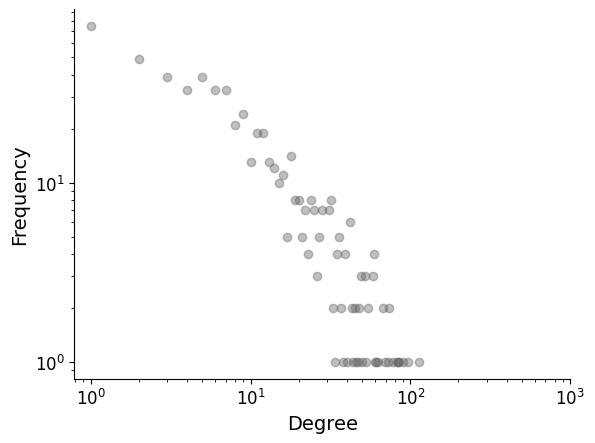

In [32]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.pyplot import figure
from matplotlib.ticker import MaxNLocator

#Let's plot the Degree distribution of the EEN
fig1, ax1 = plt.subplots()
plt.scatter(degreesDDN, degreeDistributionDDNcount, c='#5F5F5F', alpha=0.4)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
ax1.set_xticks([1,10, 100, 1000])

plt.xticks(fontsize=12, rotation=0)
plt.yticks(fontsize=12, rotation=0)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
plt.savefig('Figures/GeneticNetwork_DegreeDistribution_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight") 

plt.show()
plt.close()

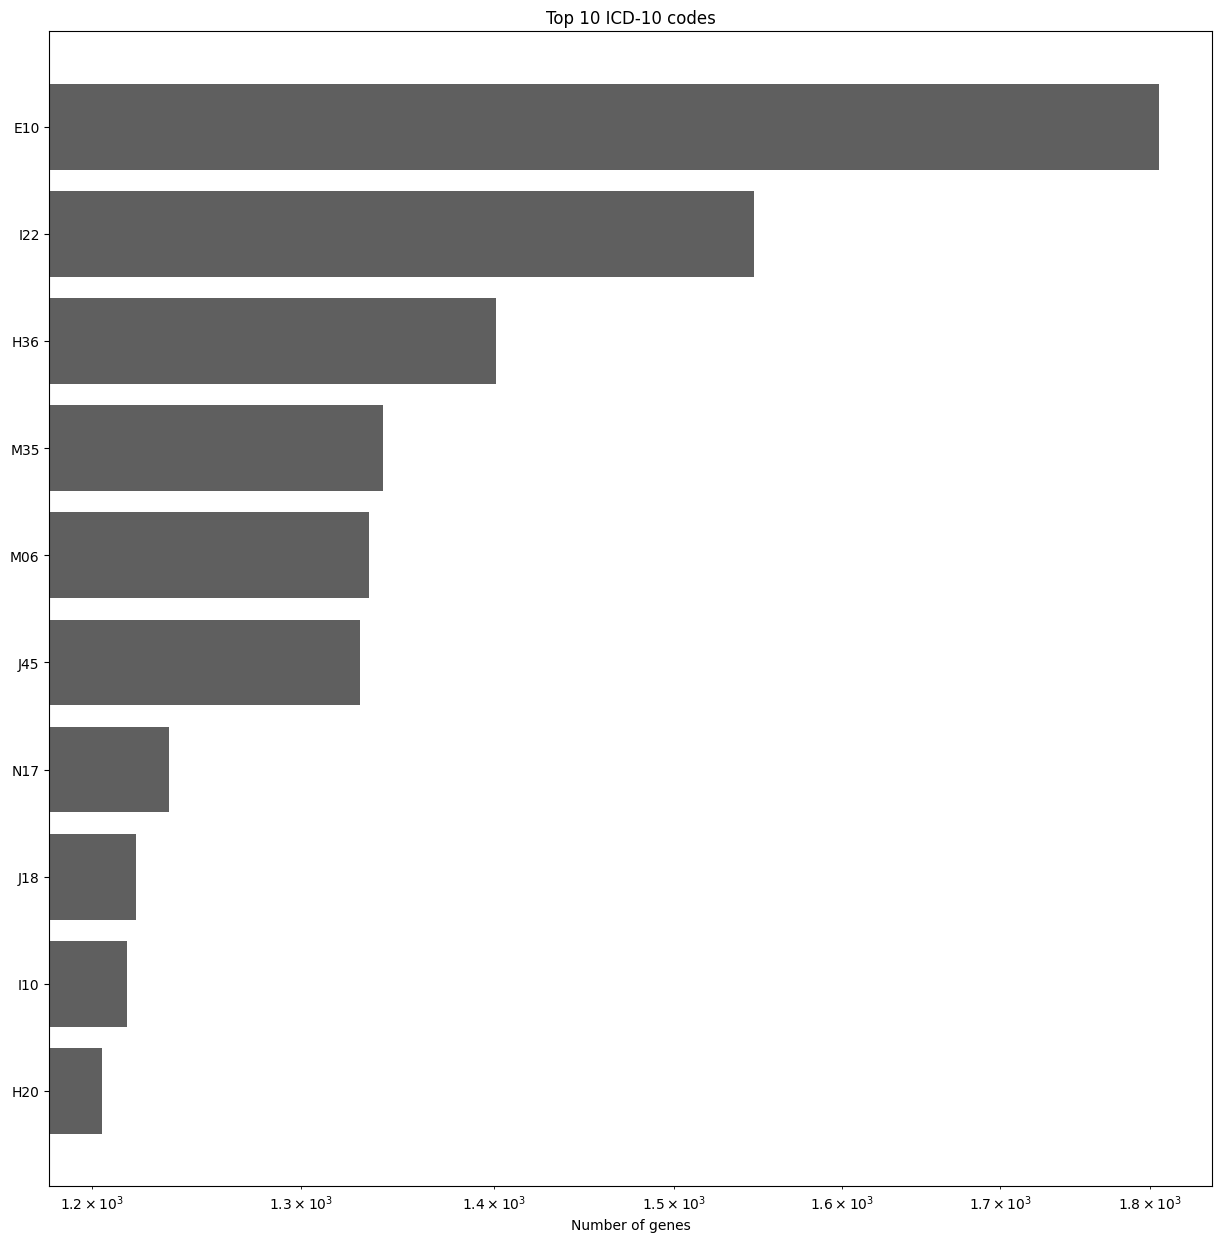

In [34]:
genelist_len = [G_gene_icd_disp_significant_post_degree[dis] for dis in list(dict(sorted(G_gene_icd_disp_significant_post_degree.items(), key=lambda item: item[1],reverse=True)).keys())[:10]] 

fig, ax = plt.subplots(figsize=(15,15))

y_pos = np.arange(10)

ax.barh(y_pos, genelist_len, align='center', color='#5F5F5F')
ax.set_yticks(y_pos, labels=list(dict(sorted(G_gene_icd_disp_significant_post_degree.items(), key=lambda item: item[1],reverse=True)).keys())[:10])
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xscale('log')
ax.set_xlabel('Number of genes')
ax.set_title('Top 10 ICD-10 codes')

plt.savefig('Figures/SF2D_TopICD10codesdegree_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight") 
plt.savefig('Figures/SF2D_TopICD10codesdegree_v2026_official.png',format='png',dpi=300, bbox_inches = "tight") 
plt.show()



In [35]:
import numpy as np

same_chapter_weights = []
different_chapter_weights = []

for u, v, data in G_gene_icd_disp_significant_post.edges(data=True):

    w = data.get("weight", None)
    if w is None:
        continue

    chap_u = icd_chapter(u)
    chap_v = icd_chapter(v)

    # skip if chapter undefined
    if chap_u is None or chap_v is None:
        continue

    if chap_u == chap_v:
        same_chapter_weights.append(w)
    else:
        different_chapter_weights.append(w)

In [36]:
print(np.median(same_chapter_weights),np.median(different_chapter_weights))

13.320243638069384 8.101871940418327


In [37]:
from scipy.stats import mannwhitneyu

u_stat, p_val_u = mannwhitneyu(
    same_chapter_weights,
    different_chapter_weights,
    alternative="two-sided"
)

print(f"Mann–Whitney U p-value: {p_val_u:.3e}")

Mann–Whitney U p-value: 6.182e-61


In [38]:
def p_to_stars(p):
    if p < 1e-4:
        return "****"
    elif p < 1e-3:
        return "***"
    elif p < 1e-2:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

sig_label = p_to_stars(p_val_u)

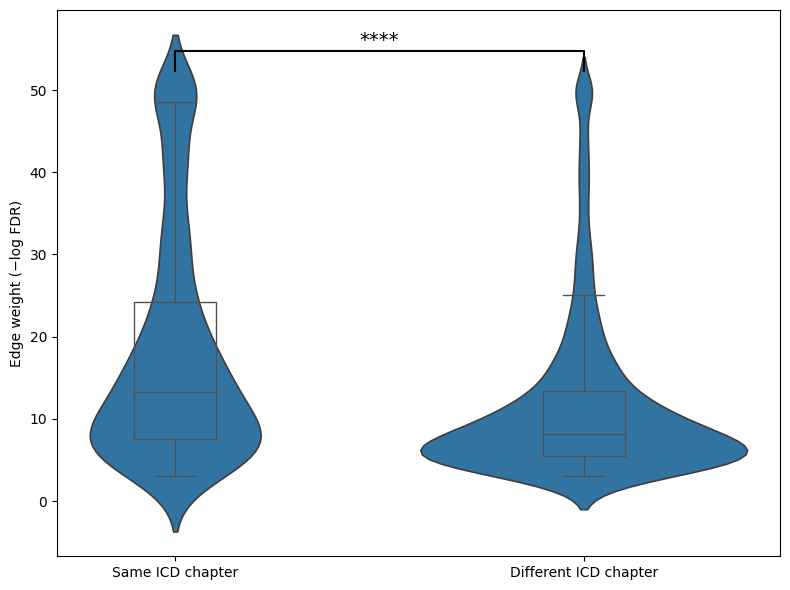

In [39]:


df_plot = pd.DataFrame({
    "weight": np.concatenate([same_chapter_weights, different_chapter_weights]),
    "group": (["Same ICD chapter"] * len(same_chapter_weights)) +
             (["Different ICD chapter"] * len(different_chapter_weights))
})

fig, ax = plt.subplots(figsize=(8,6))

sns.violinplot(
    data=df_plot,
    x="group",
    y="weight",
    inner=None,
    ax=ax
)

sns.boxplot(
    data=df_plot,
    x="group",
    y="weight",
    width=0.2,
    showcaps=True,
    boxprops={"facecolor":"none"},
    showfliers=False,
    ax=ax
)

# ---- significance bar ----
y_max = df_plot["weight"].max()
y_min = df_plot["weight"].min()
h = 0.05 * (y_max - y_min)   # height of bar
y = y_max + h

ax.plot([0, 0, 1, 1], [y, y+h, y+h, y], lw=1.5, c="black")
ax.text(0.5, y + h*1.1, sig_label, ha="center", va="bottom", fontsize=14)

ax.set_ylabel("Edge weight (−log FDR)")
ax.set_xlabel("")

plt.tight_layout()

plt.savefig('Figures/GeneticNetwork_WeightComparison_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight") 
plt.show()

In [40]:


# -----------------------------
# 1. Build plotting dataframe
# -----------------------------
df_plot = pd.DataFrame({
    "weight": np.concatenate([same_chapter_weights, different_chapter_weights]),
    "group": (["Same ICD chapter"] * len(same_chapter_weights)) +
             (["Different ICD chapter"] * len(different_chapter_weights))
})

# Sort for deterministic ordering (important)
df_plot = df_plot.sort_values(["group", "weight"]).reset_index(drop=True)

# -----------------------------
# 2. Add metadata rows (significance label)
# -----------------------------
metadata_df = pd.DataFrame({
    "weight": [None],
    "group": [None],
    "metadata": [f"Significance label used in figure: {sig_label}"]
})

# Ensure consistent columns
df_plot["metadata"] = None

# Combine data + metadata
source_df = pd.concat([df_plot, metadata_df], ignore_index=True)

# -----------------------------
# 3. Save single sheet
# -----------------------------

excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl",mode="a") as writer:
    source_df.to_excel(writer, sheet_name="Fig2B", index=False)

print(f"Source data saved to {excel_path}")

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_38353/1023483923.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  source_df = pd.concat([df_plot, metadata_df], ignore_index=True)


Source data saved to output/SourceData.xlsx


In [41]:
import community as community_louvain

def optimal_resolution(G, resolution_list,weight,random_state):
    """
    Param:
    G: A networkx graph
    resolution_list: List of resolution values to check
    """
    res_mod_dict = {}
    max_modularity = -1 # initialize maximum modularity as negative value
    for resolution in resolution_list:
        partition = community_louvain.best_partition(G, resolution=resolution,weight=weight,random_state=random_state)
        modularity = community_louvain.modularity(partition,G)
        res_mod_dict[resolution] = modularity

        if modularity > max_modularity:   # save the partition and resolution giving the maximum modularity
            max_modularity = modularity
            best_partition = partition
            best_resolution = resolution
            
    return best_partition, best_resolution, max_modularity,res_mod_dict

In [42]:
resolution_list = np.linspace(0.1, 2, 20) 

best_partition, best_resolution, max_modularity, res_mod_dict = optimal_resolution(G_gene_icd_disp_significant_post, resolution_list,'weight',5495)
print('Optimal resolution value: ', best_resolution)


Optimal resolution value:  1.0999999999999999


In [43]:
G_gene_icd_partition = community_louvain.best_partition(G_gene_icd_disp_significant_post,weight='weight',resolution=1.1)

In [44]:
len(set(G_gene_icd_partition.values()))

29

In [45]:
G_gene_icd_com={}

for com in set(G_gene_icd_partition.values()):
    dislist=[]
    for dis,comcom in G_gene_icd_partition.items():
        if com==comcom:
            dislist.append(dis)
    G_gene_icd_com[com]=dislist
    

In [46]:
with open('output/G_gene_icd_com_v2026_official.pickle', 'wb') as handle:
    pk.dump(G_gene_icd_com, handle, protocol=pk.HIGHEST_PROTOCOL)

In [47]:
with open('output/G_gene_icd_com_v2026_official.pickle', 'rb') as handle:
    G_gene_icd_com = pk.load(handle)

In [48]:

from collections import defaultdict

G_gene_icd_ICD_partition = defaultdict(list)

for node in G_gene_icd_disp_significant_post.nodes():
    chapter = icd_chapter(node)   # <- chapter assignment
    if chapter is not None:
        G_gene_icd_ICD_partition[chapter].append(node)

# convert to plain dict if you prefer
G_gene_icd_ICD_partition = dict(G_gene_icd_ICD_partition)


In [49]:

with open('output/G_gene_icd_ICD_partition_v2026_official.pickle', 'wb') as handle:
    pk.dump(G_gene_icd_ICD_partition, handle, protocol=pk.HIGHEST_PROTOCOL)

In [50]:
com_source=[]
com_target=[]
value_list=[]
com_label=list(G_gene_icd_ICD_partition.keys())+["Louvain_"+str(com2) for com2 in list(G_gene_icd_com.keys())]

for com1,dislist1 in G_gene_icd_ICD_partition.items():
    for com2,dislist2 in G_gene_icd_com.items():
        com1_name=str(com1)
        com2_name="Louvain_"+str(com2)
        com_source_index=com_label.index(com1_name)
        com_target_index=com_label.index(com2_name)
        for dis in dislist1:
            if dis in dislist2:
                com_source.append(com_source_index)
                com_target.append(com_target_index)
                value_list.append(1)
        #value_list.append(ov*10000)
        #value_list.append(10)

node_colors = []

for label in com_label:
    # ICD chapters
    if label in chapter_colors:
        node_colors.append(chapter_colors[label])
    # Louvain communities → neutral color
    else:
        node_colors.append("#B0B0B0")  # light grey


In [51]:
import plotly.graph_objects as go
import kaleido

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.1),
        label=com_label,
        color=node_colors      
    ),
    link=dict(
        source=com_source,
        target=com_target,
        value=value_list,
        line=dict(color="rgba(0,0,0,0.2)", width=0.1)
    )
)])


fig.update_layout(title_text="DDN Communities comparison", font_size=10)
fig.show()
fig.write_image("Figures/Fig2A_v2026_official.pdf", engine="kaleido")

In [69]:
import pandas as pd

rows = []

# -----------------------------
# 1. Save Nodes
# -----------------------------
for idx, (label, color) in enumerate(zip(com_label, node_colors)):
    rows.append({
        "table_type": "node",
        "node_id": idx,
        "node_label": label,
        "node_color": color,
        "source_id": None,
        "target_id": None,
        "source_label": None,
        "target_label": None,
        "value": None
    })

# -----------------------------
# 2. Save Links
# -----------------------------
for s, t, v in zip(com_source, com_target, value_list):
    rows.append({
        "table_type": "link",
        "node_id": None,
        "node_label": None,
        "node_color": None,
        "source_id": s,
        "target_id": t,
        "source_label": com_label[s],
        "target_label": com_label[t],
        "value": v
    })

# -----------------------------
# 3. Create DataFrame
# -----------------------------
source_df = pd.DataFrame(rows)

# Deterministic ordering
source_df = source_df.sort_values(
    by=["table_type", "node_id", "source_id"],
    na_position="last"
).reset_index(drop=True)

# -----------------------------
# 4. Save Single Sheet
# -----------------------------

excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl",mode="a") as writer:
    source_df.to_excel(writer, sheet_name="Fig2D", index=False)

print(f"Source data saved to {excel_path}")

Source data saved to output/SourceData.xlsx


In [54]:
for com1,dislist1 in G_gene_icd_ICD_partition.items():
    for com2,dislist2 in G_gene_icd_com.items():
        ov=float(overlap_jaccard(dislist1,dislist2))
        if ov>0.5:
            print(com1,com2,ov)



II 4 0.5625


In [55]:

louvain_cat_genedict = {}
for com_louvain,dislist in G_gene_icd_com.items():
    genelist = []
    for dis in dislist:
        genelist.extend(list(allsources_icd_gene_dict_unified[dis]))
    louvain_cat_genedict[com_louvain] = set(genelist)
        
    

In [56]:
#Let's calculate the lcc z-score

#Let's import the PPI
ppi = pd.read_csv("input/autocore_ppi_symbol_lcc.csv",delimiter= ',',
           skipinitialspace=True)
G_ppi = nx.from_pandas_edgelist(ppi, 'symbol1', 'symbol2')

def net_modularity(genelist,network):
    geneset=set(genelist)&network.nodes()
    if len(geneset)>2:
        G_sub = nx.subgraph(network,geneset)
        Gsub_lcc = G_sub.subgraph(max(nx.connected_components(G_sub), key=len))  # extract lcc graph
        number_of_connected_component=Gsub_lcc.number_of_nodes()
        f_lcc_size = Gsub_lcc.number_of_nodes()
        l_random_lccs = []
        S = 1000
        for s in range(S):
            gene_sample = rd.sample(list(network.nodes()),len(geneset))
            G_sub_rnd = nx.subgraph(network,gene_sample)
            G_sub_rnd_lcc = G_sub_rnd.subgraph(max(nx.connected_components(G_sub_rnd), key=len))  # extract lcc graph
            lcc_size = G_sub_rnd_lcc.number_of_nodes()
            l_random_lccs.append(lcc_size)
        mu = np.mean(l_random_lccs)
        std = np.std(l_random_lccs)
        z = (f_lcc_size-mu)/std
    else:
        number_of_connected_component=0
        z='nan'
    return z


In [57]:
#We need compare the same diseases occurring in the Molecular DDN

icd_cat_genedict = {}
for icd_cat,dis_list in G_gene_icd_ICD_partition.items():
    genelist = []
    for dis in dis_list:
        genelist.extend(list(allsources_icd_gene_dict_unified[dis]))
    icd_cat_genedict[icd_cat] = list(set(genelist))


In [58]:
icd_cat_genedict_lcc_dict = {}
louvain_cat_genedict_lcc_dict = {}

for com,geneset in icd_cat_genedict.items():
    icd_cat_genedict_lcc_dict[com] = net_modularity(geneset,G_ppi)
    
for com,geneset in louvain_cat_genedict.items():
    louvain_cat_genedict_lcc_dict[com] = net_modularity(geneset,G_ppi)

In [62]:
allsources_icd_gene_dict_unified_lcczscore_DDN = {}
for icd,z in allsources_icd_gene_dict_unified_lcczscore.items():
    if icd in G_gene_icd_disp_significant_post.nodes():
        allsources_icd_gene_dict_unified_lcczscore_DDN[icd] = z



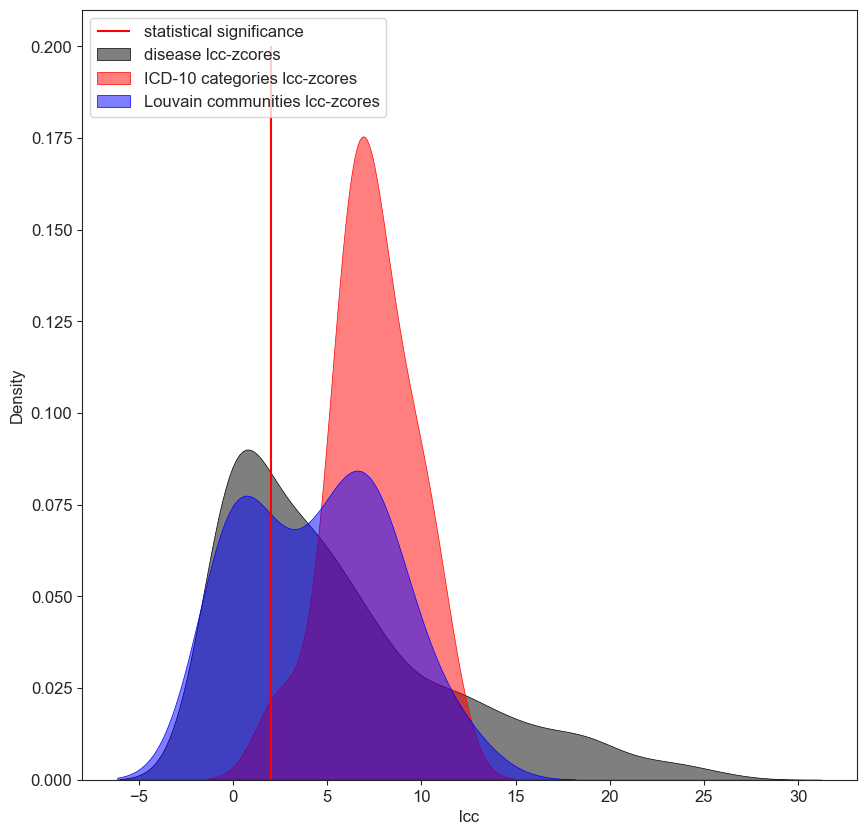

In [63]:
#Let's plot the distribution of all lcc z-scores
import seaborn as sns
icd_lcc_zscores = [i for i in icd_cat_genedict_lcc_dict.values() if str(i)!='nan']
louvain_lcc_zscores = [i for i in louvain_cat_genedict_lcc_dict.values() if str(i)!='nan']
lcc_zscores = [i for i in allsources_icd_gene_dict_unified_lcczscore_DDN.values() if str(i)!='nan']

# plot distributions for non-sampled case
sns.set_style('white')
sns.set_style("ticks", {"xtick.major.size": 15, "ytick.major.size": 15})
plt.figure(figsize=(10,10))
plt.vlines(2,ymin=0,ymax=0.2,color='r',label='statistical significance')
sns.kdeplot(lcc_zscores,color='k',lw=.5,alpha=.5,fill=True,label='disease lcc-zcores')
sns.kdeplot(icd_lcc_zscores,color='r',lw=.5,alpha=.5,fill=True,label='ICD-10 categories lcc-zcores')
sns.kdeplot(louvain_lcc_zscores,color='b',lw=.5,alpha=.5,fill=True,label='Louvain communities lcc-zcores')
plt.legend(loc='upper left',fontsize=12)
plt.ylabel('Density',fontsize=12)
plt.xlabel('lcc',fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.savefig('Figures/Fig2B_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")

In [70]:

icd_lcc_zscores = [i for i in icd_cat_genedict_lcc_dict.values() if pd.notna(i)]
louvain_lcc_zscores = [i for i in louvain_cat_genedict_lcc_dict.values() if pd.notna(i)]
lcc_zscores = [i for i in allsources_icd_gene_dict_unified_lcczscore_DDN.values() if pd.notna(i)]

# -----------------------------
# 2. Build Long-Format DataFrame
# -----------------------------
df_plot = pd.DataFrame({
    "lcc_zscore": (
        lcc_zscores +
        icd_lcc_zscores +
        louvain_lcc_zscores
    ),
    "group": (
        ["Disease"] * len(lcc_zscores) +
        ["ICD-10 category"] * len(icd_lcc_zscores) +
        ["Louvain community"] * len(louvain_lcc_zscores)
    )
})

# Deterministic ordering
df_plot = df_plot.sort_values(["group", "lcc_zscore"]).reset_index(drop=True)

# -----------------------------
# 3. Add Metadata (threshold)
# -----------------------------
df_plot["metadata"] = None

metadata_rows = pd.DataFrame({
    "lcc_zscore": [None],
    "group": [None],
    "metadata": ["Vertical significance threshold used in plot: z = 2"]
})

source_df = pd.concat([df_plot, metadata_rows], ignore_index=True)

excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl",mode="a") as writer:
    source_df.to_excel(writer, sheet_name="Fig2E", index=False)

print(f"Source data saved to {excel_path}")

Source data saved to output/SourceData.xlsx


In [64]:
from scipy.stats import mannwhitneyu

# Perform the Wilcoxon rank-sum test (Mann-Whitney U test)
result = mannwhitneyu(louvain_lcc_zscores, icd_lcc_zscores, alternative='two-sided')
result

MannwhitneyuResult(statistic=112.0, pvalue=0.01899761204173977)

In [65]:
# Perform the Wilcoxon rank-sum test (Mann-Whitney U test)
result = mannwhitneyu(louvain_lcc_zscores, lcc_zscores, alternative='two-sided')
result

MannwhitneyuResult(statistic=7652.0, pvalue=0.7133918761580065)

In [66]:
# Perform the Wilcoxon rank-sum test (Mann-Whitney U test)
result = mannwhitneyu(icd_lcc_zscores, lcc_zscores, alternative='two-sided')
result

MannwhitneyuResult(statistic=5289.0, pvalue=0.0168904936755352)

In [67]:
np.median(icd_lcc_zscores)

7.069488610520491

In [68]:
np.median(louvain_lcc_zscores)

4.855188684424345